# Sigless Failed-Run Chunking and Exploratory Analysis

This notebook now targets failed-run replay logs and:
1. Chunks `logs/sigless.failed.CH1-0.csv` into individual runs based on `start`/`end` `MESSAGE` markers.
2. Uses `logs/sigless.failed.CH2-0.csv` as overflow power readings and adds them to CH1 power.
3. Saves one CSV per complete run in `logs/chunked_sigless_runs/`.
4. Computes run-level metrics (duration, energy, average power, peak power).
5. Compares run groups (for example `queryA` vs `queryB`) using visualizations and a permutation test.

Incomplete tail runs (missing `end`) are skipped by default.

In [1]:
import csv
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [2]:
raw_sigless_file = Path("logs/sigless.failed.CH1-0.csv")
overflow_sigless_file = Path("logs/sigless.failed.CH2-0.csv")
chunk_output_dir = Path("logs/chunked_sigless_runs")
chunk_output_dir.mkdir(parents=True, exist_ok=True)

metadata_output_file = chunk_output_dir / "run_metadata.csv"
analysis_output_file = chunk_output_dir / "run_analysis.csv"

# Optional filter; set to a run_id string to narrow processing, or None for all runs.
RUN_ID_FILTER = None

# Skip runs that never emitted an `end` marker (common in interrupted/failed captures).
SKIP_INCOMPLETE_RUNS = True

# Max timestamp distance when matching CH2 overflow samples to CH1 base samples.
OVERFLOW_MATCH_TOLERANCE_MS = 20

print(f"Primary input (CH1): {raw_sigless_file.resolve()}")
print(f"Overflow input (CH2): {overflow_sigless_file.resolve()}")
print(f"Chunk output dir: {chunk_output_dir.resolve()}")
print(f"Run ID filter: {RUN_ID_FILTER}")
print(f"Skip incomplete runs: {SKIP_INCOMPLETE_RUNS}")
print(f"Overflow match tolerance (ms): {OVERFLOW_MATCH_TOLERANCE_MS}")

Primary input (CH1): C:\Users\matth\Desktop\Masters-Thesis\logs\sigless.failed.CH1-0.csv
Overflow input (CH2): C:\Users\matth\Desktop\Masters-Thesis\logs\sigless.failed.CH2-0.csv
Chunk output dir: C:\Users\matth\Desktop\Masters-Thesis\logs\chunked_sigless_runs
Run ID filter: None
Skip incomplete runs: True
Overflow match tolerance (ms): 20


In [3]:
def parse_message_payload(payload: str) -> dict:
    payload_obj = json.loads(payload)
    message_text = payload_obj.get("message", "")

    message_fields = {
        "action": None,
        "channelId": payload_obj.get("channelId"),
        "message_timestamp": payload_obj.get("timestamp"),
    }

    parts = [p.strip() for p in message_text.split(",") if p.strip()]
    if parts:
        message_fields["action"] = parts[0].lower()

    for token in parts[1:]:
        if "=" in token:
            key, value = token.split("=", 1)
            message_fields[key.strip()] = value.strip()

    return message_fields


def sanitize_filename(name: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", name).strip("_")


def make_chunk_filename(run_meta: dict) -> str:
    run_id = sanitize_filename(str(run_meta.get("run_id", "run")))
    test_name = sanitize_filename(str(run_meta.get("test", "unknown_test")))
    loop_name = sanitize_filename(str(run_meta.get("loop", "loop_unknown")))
    return f"{run_id}__{test_name}__{loop_name}.csv"

In [4]:
overflow_df = pd.DataFrame(columns=["timestamp", "overflow_w"])
if overflow_sigless_file.exists():
    overflow_raw = pd.read_csv(overflow_sigless_file)
    overflow_raw = overflow_raw[overflow_raw["action"].astype(str).str.startswith("POWER")].copy()
    overflow_raw["timestamp"] = pd.to_numeric(overflow_raw["timestamp"], errors="coerce")
    overflow_raw["overflow_w"] = pd.to_numeric(overflow_raw["payload"], errors="coerce")
    overflow_df = overflow_raw.dropna(subset=["timestamp", "overflow_w"])[["timestamp", "overflow_w"]].copy()
    overflow_df["timestamp"] = overflow_df["timestamp"].astype("int64")
    overflow_df = overflow_df.sort_values("timestamp").reset_index(drop=True)

run_records = []
active_run = None
active_power_rows = []
skipped_incomplete_runs = 0

def finalize_active_run(active_run_meta: dict, active_rows: list, run_end_ts: int | None):
    local_run = dict(active_run_meta)
    if run_end_ts is None:
        local_run["status"] = "incomplete_missing_end"
        local_run["power_samples"] = len(active_rows)
        local_run["chunk_file"] = None
        return local_run

    local_run["end_ts"] = run_end_ts
    power_df = pd.DataFrame(active_rows)

    if not power_df.empty and not overflow_df.empty:
        overflow_window = overflow_df[
            (overflow_df["timestamp"] >= local_run["start_ts"]) &
            (overflow_df["timestamp"] <= run_end_ts)
        ].copy()

        if not overflow_window.empty:
            power_df = power_df.sort_values("timestamp").reset_index(drop=True)
            merged = pd.merge_asof(
                power_df,
                overflow_window.sort_values("timestamp"),
                on="timestamp",
                direction="nearest",
                tolerance=OVERFLOW_MATCH_TOLERANCE_MS,
            )
            merged["overflow_w"] = merged["overflow_w"].fillna(0.0)
            merged["power_w_base"] = merged["power_w"]
            merged["power_w"] = merged["power_w_base"] + merged["overflow_w"]
            power_df = merged
        else:
            power_df["overflow_w"] = 0.0
            power_df["power_w_base"] = power_df["power_w"]
    elif not power_df.empty:
        power_df["overflow_w"] = 0.0
        power_df["power_w_base"] = power_df["power_w"]

    if not power_df.empty:
        chunk_file = chunk_output_dir / make_chunk_filename(local_run)
        power_df.to_csv(chunk_file, index=False)

        local_run["chunk_file"] = str(chunk_file)
        local_run["power_samples"] = int(power_df.shape[0])
        local_run["status"] = "complete"
    else:
        local_run["chunk_file"] = None
        local_run["power_samples"] = 0
        local_run["status"] = "complete_no_power_rows"

    return local_run

with raw_sigless_file.open("r", newline="", encoding="utf-8") as handle:
    reader = csv.reader(handle)
    header = next(reader, None)

    for row in reader:
        if len(row) < 4:
            continue

        timestamp_raw, channel, action, payload = row[0], row[1], row[2].strip(), row[3]

        try:
            timestamp = int(timestamp_raw)
        except ValueError:
            continue

        if action == "MESSAGE":
            try:
                msg = parse_message_payload(payload)
            except json.JSONDecodeError:
                continue

            msg_action = msg.get("action")

            if msg_action == "start":
                msg_run_id = str(msg.get("run_id", ""))
                if RUN_ID_FILTER and msg_run_id != RUN_ID_FILTER:
                    continue

                if active_run is not None:
                    finalized = finalize_active_run(active_run, active_power_rows, run_end_ts=None)
                    if SKIP_INCOMPLETE_RUNS and finalized["status"] == "incomplete_missing_end":
                        skipped_incomplete_runs += 1
                    else:
                        run_records.append(finalized)

                active_run = {
                    **msg,
                    "channel": channel,
                    "start_ts": timestamp,
                    "status": "open",
                }
                active_power_rows = []

            elif msg_action == "end" and active_run is not None:
                active_run["elapsed_sec_message"] = float(msg.get("elapsed_sec", np.nan)) if "elapsed_sec" in msg else np.nan
                active_run["failures"] = int(msg.get("failures", -1)) if "failures" in msg else np.nan

                finalized = finalize_active_run(active_run, active_power_rows, run_end_ts=timestamp)
                run_records.append(finalized)

                active_run = None
                active_power_rows = []

        elif action.startswith("POWER") and active_run is not None and channel == "CH1":
            try:
                power_val = float(payload)
            except ValueError:
                continue

            active_power_rows.append(
                {
                    "timestamp": timestamp,
                    "channel": channel,
                    "action": action,
                    "power_w": power_val,
                }
            )

if active_run is not None:
    finalized = finalize_active_run(active_run, active_power_rows, run_end_ts=None)
    if SKIP_INCOMPLETE_RUNS and finalized["status"] == "incomplete_missing_end":
        skipped_incomplete_runs += 1
    else:
        run_records.append(finalized)

runs_df = pd.DataFrame(run_records)
if not runs_df.empty:
    runs_df["message_duration_sec"] = (runs_df.get("end_ts", np.nan) - runs_df["start_ts"]) / 1000.0
    runs_df.to_csv(metadata_output_file, index=False)

print(f"Runs found (after filter/skip rules): {len(runs_df)}")
print(f"Incomplete tail runs skipped: {skipped_incomplete_runs}")
print(runs_df["status"].value_counts(dropna=False) if not runs_df.empty else "No runs found")
runs_df.head()

Runs found (after filter/skip rules): 507
Incomplete tail runs skipped: 1
status
complete    507
Name: count, dtype: int64


,action,channelId,message_timestamp,run_id,test,loop,runs,channel,start_ts,status,elapsed_sec_message,failures,end_ts,chunk_file,power_samples,message_duration_sec
0,start,CH1,1773666255058,278870BD30288202,APX1090-queryA.sql,1/35,100,CH1,1773666255058,complete,117.458628,0,1773666372531,logs\chunked_sigless_runs\278870BD30288202__AP...,10695,117.473
1,start,CH1,1773666387554,278870BD30288202,APX1090-queryA.sql,2/35,100,CH1,1773666387554,complete,116.036479,0,1773666503605,logs\chunked_sigless_runs\278870BD30288202__AP...,10329,116.051
2,start,CH1,1773666518627,278870BD30288202,APX1090-queryA.sql,3/35,100,CH1,1773666518627,complete,115.661809,0,1773666634303,logs\chunked_sigless_runs\278870BD30288202__AP...,10110,115.676
3,start,CH1,1773666649326,278870BD30288202,APX1090-queryA.sql,4/35,100,CH1,1773666649326,complete,116.285402,0,1773666765625,logs\chunked_sigless_runs\278870BD30288202__AP...,10326,116.299
4,start,CH1,1773666780648,278870BD30288202,APX1090-queryA.sql,5/35,100,CH1,1773666780648,complete,115.237330,0,1773666895900,logs\chunked_sigless_runs\278870BD30288202__AP...,10289,115.252


In [5]:
analysis_records = []

for _, row in runs_df.iterrows():
    chunk_file = row.get("chunk_file")
    if not chunk_file or pd.isna(chunk_file):
        continue

    chunk_path = Path(chunk_file)
    if not chunk_path.exists():
        continue

    power_df = pd.read_csv(chunk_path)
    if power_df.empty:
        continue

    power_df = power_df.sort_values("timestamp").reset_index(drop=True)
    power_df["time_s"] = (power_df["timestamp"] - power_df["timestamp"].min()) / 1000.0

    measured_window_sec = float(power_df["time_s"].iloc[-1]) if len(power_df) > 1 else 0.0
    integrate_trapezoid = getattr(np, "trapezoid", np.trapz)
    energy_j = float(integrate_trapezoid(power_df["power_w"].to_numpy(), power_df["time_s"].to_numpy())) if len(power_df) > 1 else 0.0
    avg_power_w = energy_j / measured_window_sec if measured_window_sec > 0 else np.nan

    analysis_records.append(
        {
            "run_id": row.get("run_id"),
            "test": row.get("test"),
            "loop": row.get("loop"),
            "runs": pd.to_numeric(row.get("runs"), errors="coerce"),
            "message_duration_sec": pd.to_numeric(row.get("message_duration_sec"), errors="coerce"),
            "elapsed_sec_message": pd.to_numeric(row.get("elapsed_sec_message"), errors="coerce"),
            "power_samples": int(power_df.shape[0]),
            "measured_window_sec": measured_window_sec,
            "energy_j": energy_j,
            "avg_power_w": avg_power_w,
            "peak_power_w": float(power_df["power_w"].max()),
            "min_power_w": float(power_df["power_w"].min()),
            "std_power_w": float(power_df["power_w"].std(ddof=1)) if power_df.shape[0] > 1 else 0.0,
            "chunk_file": str(chunk_path),
        }
    )

analysis_df = pd.DataFrame(analysis_records)
if not analysis_df.empty:
    analysis_df["query_group"] = analysis_df["test"].str.extract(r"(query[AB])", expand=False).str.upper()
    analysis_df["test_id"] = analysis_df["test"].str.extract(r"^([^-]+)", expand=False)
    analysis_df.to_csv(analysis_output_file, index=False)

print(f"Analyzed runs: {len(analysis_df)}")
analysis_df.head()

Analyzed runs: 507


,run_id,test,loop,runs,message_duration_sec,elapsed_sec_message,power_samples,measured_window_sec,energy_j,avg_power_w,peak_power_w,min_power_w,std_power_w,chunk_file,query_group,test_id
0,278870BD30288202,APX1090-queryA.sql,1/35,100,117.473,117.458628,10695,117.450,1958.910220,16.678674,18.92,16.18,0.362873,logs\chunked_sigless_runs\278870BD30288202__AP...,QUERYA,APX1090
1,278870BD30288202,APX1090-queryA.sql,2/35,100,116.051,116.036479,10329,116.034,1939.631970,16.716066,17.55,8.77,0.560028,logs\chunked_sigless_runs\278870BD30288202__AP...,QUERYA,APX1090
2,278870BD30288202,APX1090-queryA.sql,3/35,100,115.676,115.661809,10110,115.522,1942.098835,16.811506,17.75,8.77,0.506906,logs\chunked_sigless_runs\278870BD30288202__AP...,QUERYA,APX1090
3,278870BD30288202,APX1090-queryA.sql,4/35,100,116.299,116.285402,10326,116.295,1963.050580,16.879922,19.69,8.58,0.547011,logs\chunked_sigless_runs\278870BD30288202__AP...,QUERYA,APX1090
4,278870BD30288202,APX1090-queryA.sql,5/35,100,115.252,115.237330,10289,115.237,1932.399975,16.768919,22.03,8.39,0.738579,logs\chunked_sigless_runs\278870BD30288202__AP...,QUERYA,APX1090


Run-level summary of available data:


,run_id,test,query_group,avg_power_w,peak_power_w,energy_j,measured_window_sec,power_samples
0,278870BD30288202,APX1090-queryA.sql,QUERYA,16.678674,18.92,1958.910220,117.450,10695
1,278870BD30288202,APX1090-queryA.sql,QUERYA,16.716066,17.55,1939.631970,116.034,10329
2,278870BD30288202,APX1090-queryA.sql,QUERYA,16.811506,17.75,1942.098835,115.522,10110
3,278870BD30288202,APX1090-queryA.sql,QUERYA,16.879922,19.69,1963.050580,116.295,10326
4,278870BD30288202,APX1090-queryA.sql,QUERYA,16.768919,22.03,1932.399975,115.237,10289
...,...,...,...,...,...,...,...,...
502,278870BD30288202,APX1278-queryA.sql,QUERYA,17.355831,18.72,1505.479455,86.742,7507
503,278870BD30288202,APX1278-queryA.sql,QUERYA,17.356767,18.72,1505.057335,86.713,7779
504,278870BD30288202,APX1278-queryA.sql,QUERYA,12.278810,13.45,226.359870,18.435,1737
505,278870BD30288202,APX1278-queryA.sql,QUERYA,12.460254,13.26,209.045680,16.777,1453


Per-test A/B summary (avg_power_w):


count       mean     median       std        min  \
test_id query_group                                                     
APX1090 QUERYA          35  14.243579  13.316232  1.808721  12.523949   
        QUERYB          35  12.564373  12.565617  0.028891  12.502121   
APX1092 QUERYA          35  18.389285  18.419460  0.116939  17.991895   
        QUERYB          35  18.401883  18.407905  0.099822  18.105239   
APX1130 QUERYA          35  12.539137  12.523174  0.054510  12.455297   
        QUERYB          35  12.546277  12.546336  0.014064  12.518113   
APX1145 QUERYA          35  17.312044  17.335286  0.094664  16.957892   
        QUERYB          35  17.384132  17.381460  0.057897  17.272380   
APX1173 QUERYA          35  12.419241  12.412912  0.045952  12.366502   
        QUERYB          35  12.400522  12.402764  0.014685  12.374007   
APX1186 QUERYA          35  12.334811  12.325095  0.061245  12.244016   
        QUERYB          35  16.978946  17.023817  0.205560  16.198338   
APX1225 QUERYA          35  17.014402  17.018767  0.078925  16.845719   
        QUERYB          35  11.943004  11.932528  0.200467  11.576982   
APX1278 QUERYA          17  16.253218  17.243397  2.233854  10.259231   

                           max  
test_id query_group             
APX1090 QUERYA       16.879922  
        QUERYB       12.656484  
APX1092 QUERYA       18.561743  
        QUERYB       18.555925  
APX1130 QUERYA       12.734236  
        QUERYB       12.576341  
APX1145 QUERYA       17.426287  
        QUERYB       17.486377  
APX1173 QUERYA       12.624683  
        QUERYB       12.437256  
APX1186 QUERYA       12.607765  
        QUERYB       17.352795  
APX1225 QUERYA       17.160200  
        QUERYB       12.486022  
APX1278 QUERYA       17.357857

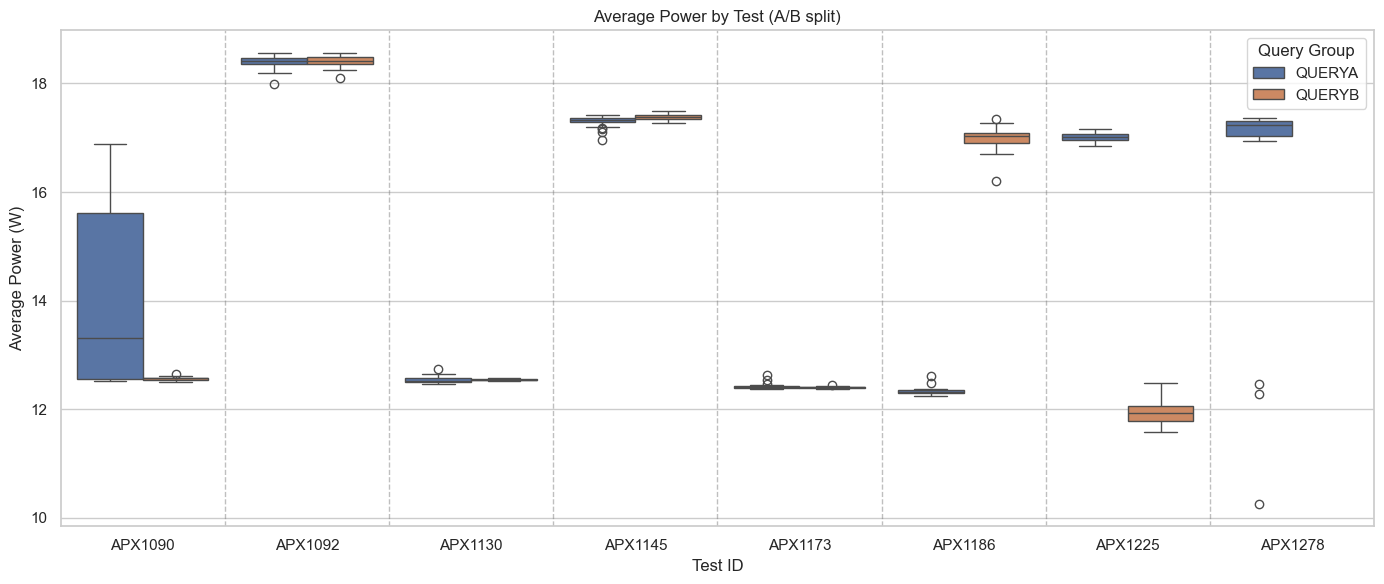

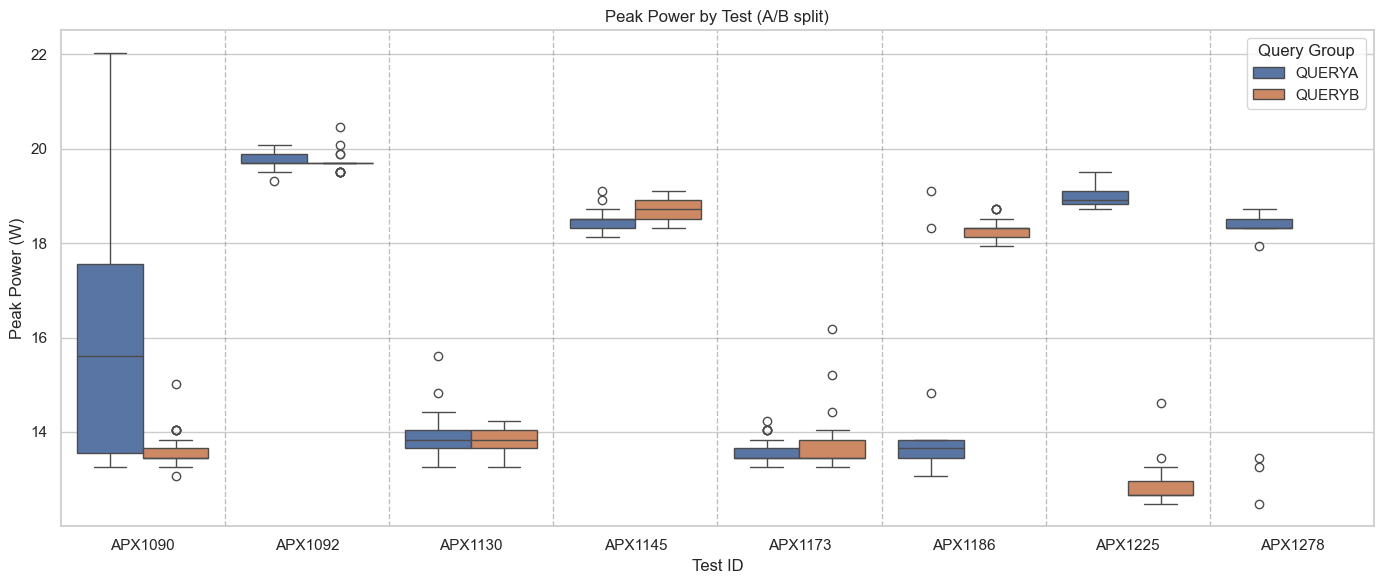

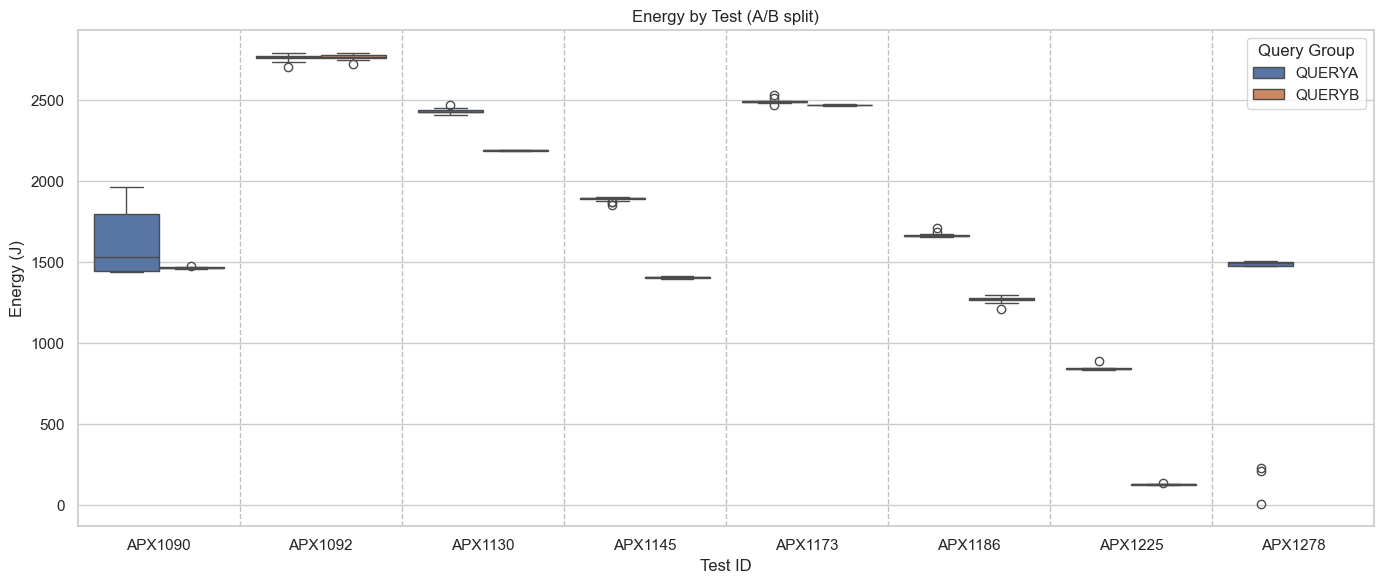

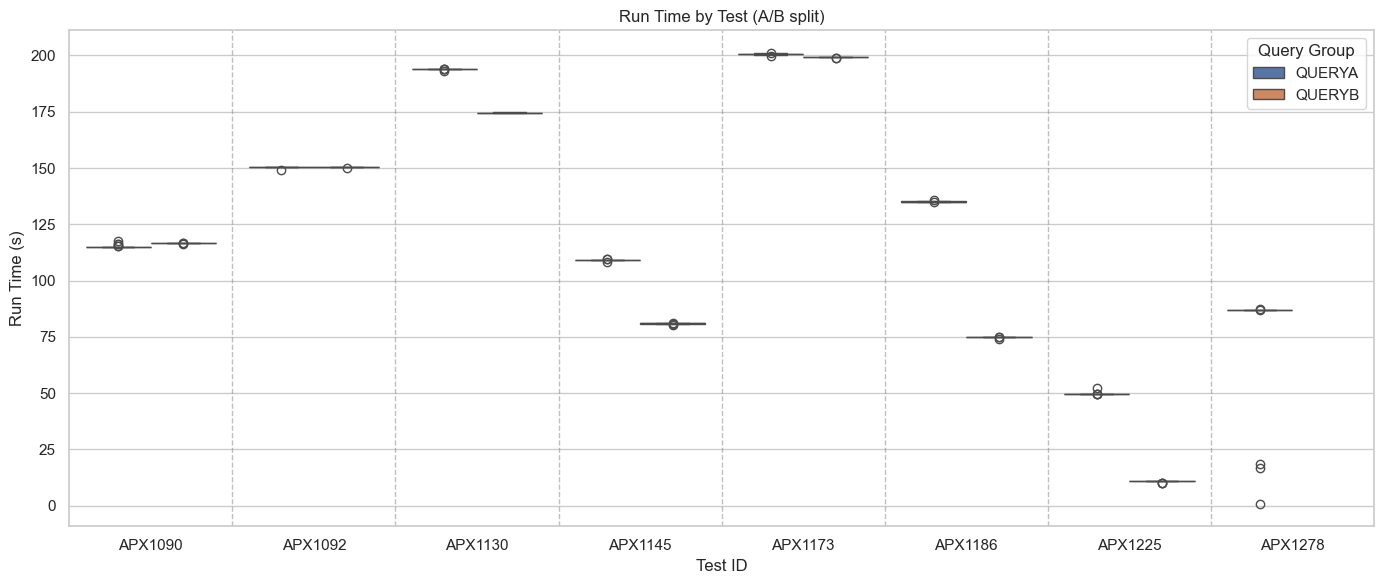

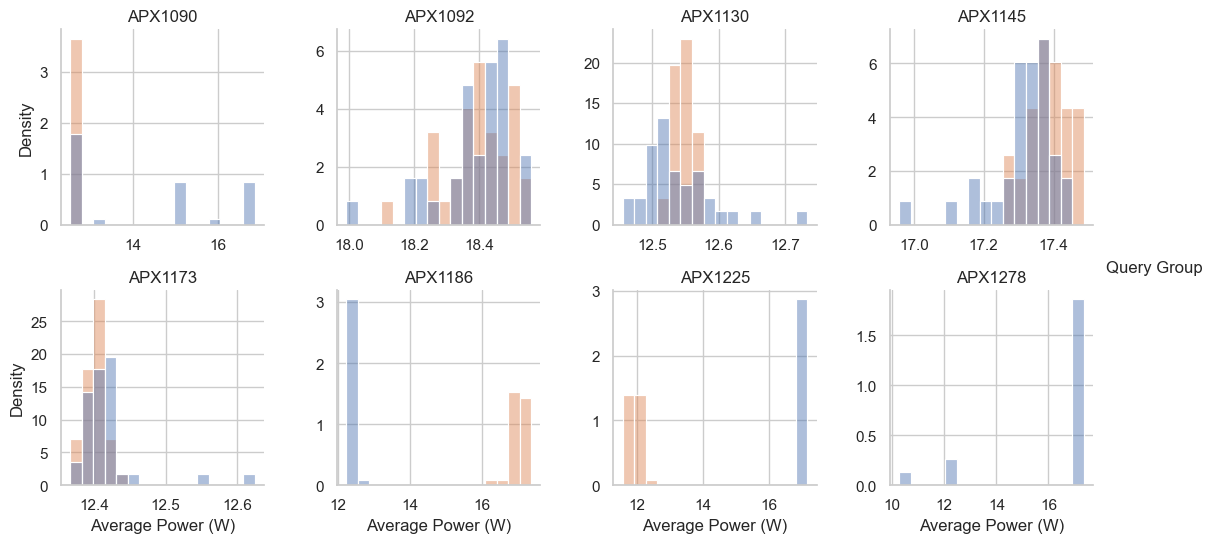

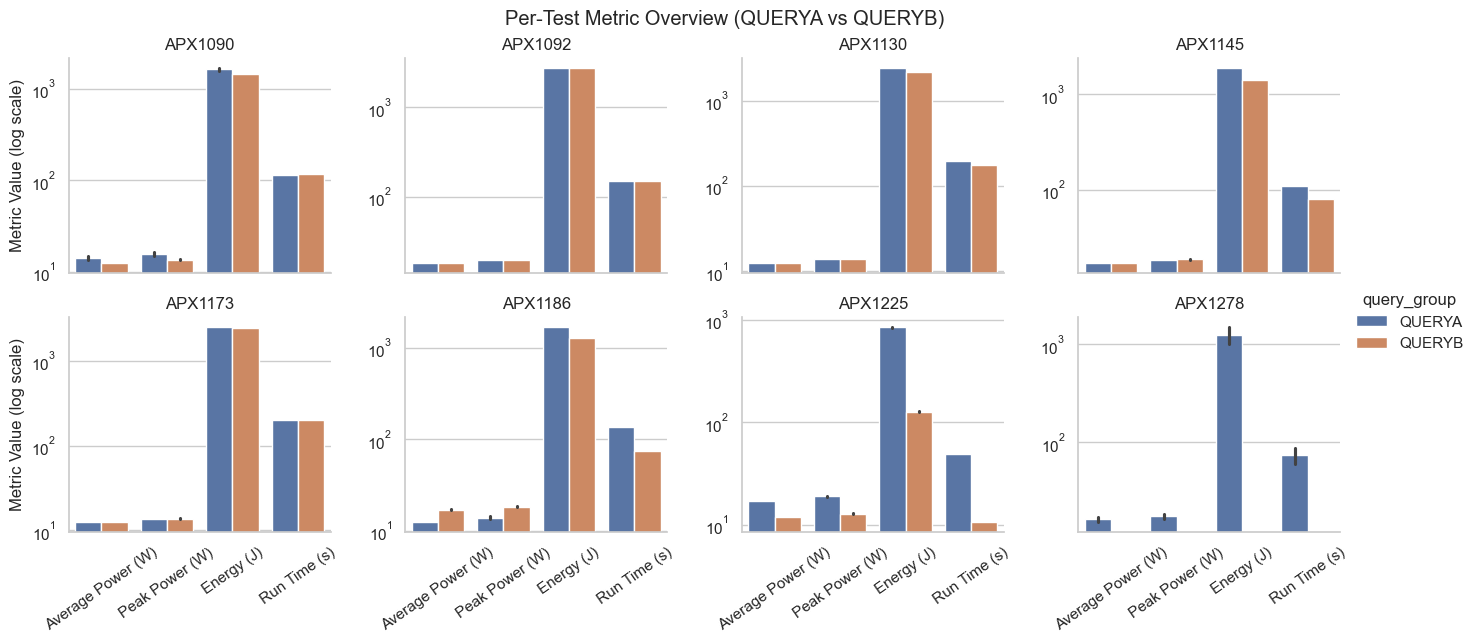

In [6]:
if analysis_df.empty:
    raise ValueError("No complete runs available for analysis.")

# Always show currently available run-level data, even if only one run exists.
summary_cols = [
    "run_id",
    "test",
    "query_group",
    "avg_power_w",
    "peak_power_w",
    "energy_j",
    "measured_window_sec",
    "power_samples",
]
available_summary_cols = [c for c in summary_cols if c in analysis_df.columns]

print("Run-level summary of available data:")
display(
    analysis_df[available_summary_cols]
    .sort_values([c for c in ["test", "run_id"] if c in analysis_df.columns])
    .reset_index(drop=True)
)

ab_df = analysis_df[analysis_df["query_group"].isin(["QUERYA", "QUERYB"])].copy()
groups_present = set(ab_df["query_group"].dropna().unique())

if {"QUERYA", "QUERYB"}.issubset(groups_present):
    print("Per-test A/B summary (avg_power_w):")
    display(
        ab_df.groupby(["test_id", "query_group"])["avg_power_w"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .sort_index()
    )

    test_order = sorted(ab_df["test_id"].dropna().unique())

    metric_plots = [
        ("avg_power_w", "Average Power by Test (A/B split)", "Average Power (W)"),
        ("peak_power_w", "Peak Power by Test (A/B split)", "Peak Power (W)"),
        ("energy_j", "Energy by Test (A/B split)", "Energy (J)"),
        ("measured_window_sec", "Run Time by Test (A/B split)", "Run Time (s)"),
    ]

    for metric_col, metric_title, metric_ylabel in metric_plots:
        plt.figure(figsize=(14, 6))
        sns.boxplot(data=ab_df, x="test_id", y=metric_col, hue="query_group", order=test_order)

        for i in range(len(test_order) - 1):
            plt.axvline(i + 0.5, color="gray", linestyle="--", linewidth=1, alpha=0.5)

        plt.title(metric_title)
        plt.xlabel("Test ID")
        plt.ylabel(metric_ylabel)
        plt.legend(title="Query Group")
        plt.tight_layout()
        plt.show()

    g = sns.FacetGrid(ab_df, col="test_id", col_wrap=4, height=2.8, sharex=False, sharey=False)
    g.map_dataframe(sns.histplot, x="avg_power_w", hue="query_group", bins=16, stat="density", common_norm=False, alpha=0.45)
    g.add_legend(title="Query Group")
    g.set_titles(col_template="{col_name}")
    g.set_axis_labels("Average Power (W)", "Density")
    plt.show()

    metrics_for_overview = ["avg_power_w", "peak_power_w", "energy_j", "measured_window_sec"]
    metric_name_map = {
        "avg_power_w": "Average Power (W)",
        "peak_power_w": "Peak Power (W)",
        "energy_j": "Energy (J)",
        "measured_window_sec": "Run Time (s)",
    }

    overview_df = ab_df[["test_id", "query_group", *metrics_for_overview]].copy()
    overview_long = overview_df.melt(
        id_vars=["test_id", "query_group"],
        value_vars=metrics_for_overview,
        var_name="metric",
        value_name="value",
    )
    overview_long = overview_long[overview_long["value"] > 0].copy()
    overview_long["metric"] = overview_long["metric"].map(metric_name_map)

    g_metrics = sns.catplot(
        data=overview_long,
        kind="bar",
        x="metric",
        y="value",
        hue="query_group",
        col="test_id",
        col_wrap=4,
        order=[metric_name_map[m] for m in metrics_for_overview],
        col_order=test_order,
        height=3.0,
        aspect=1.15,
        sharey=False,
    )
    g_metrics.set(yscale="log")
    g_metrics.set_titles(col_template="{col_name}")
    g_metrics.set_axis_labels("", "Metric Value (log scale)")

    for ax in g_metrics.axes.flatten():
        ax.tick_params(axis="x", labelrotation=35)

    g_metrics.fig.subplots_adjust(top=0.9)
    g_metrics.fig.suptitle("Per-Test Metric Overview (QUERYA vs QUERYB)")
    plt.show()
else:
    print("A/B comparison plots will appear once both QUERYA and QUERYB runs are available.")

Permutation test results by test (A vs B within each test_id):


,test_id,n_queryA,n_queryB,observed_mean_diff_A_minus_B_w,p_left_A_lt_B,p_right_A_gt_B,p_two_sided
0,APX1090,35,35,1.679206,1.000000,0.000100,0.000100
1,APX1092,35,35,-0.012598,0.312969,0.687131,0.636136
2,APX1130,35,35,-0.007140,0.237476,0.762624,0.467653
3,APX1145,35,35,-0.072088,0.000100,1.000000,0.000100
4,APX1173,35,35,0.018719,0.996400,0.003700,0.006499
5,APX1186,35,35,-4.644135,0.000100,1.000000,0.000100
6,APX1225,35,35,5.071398,1.000000,0.000100,0.000100


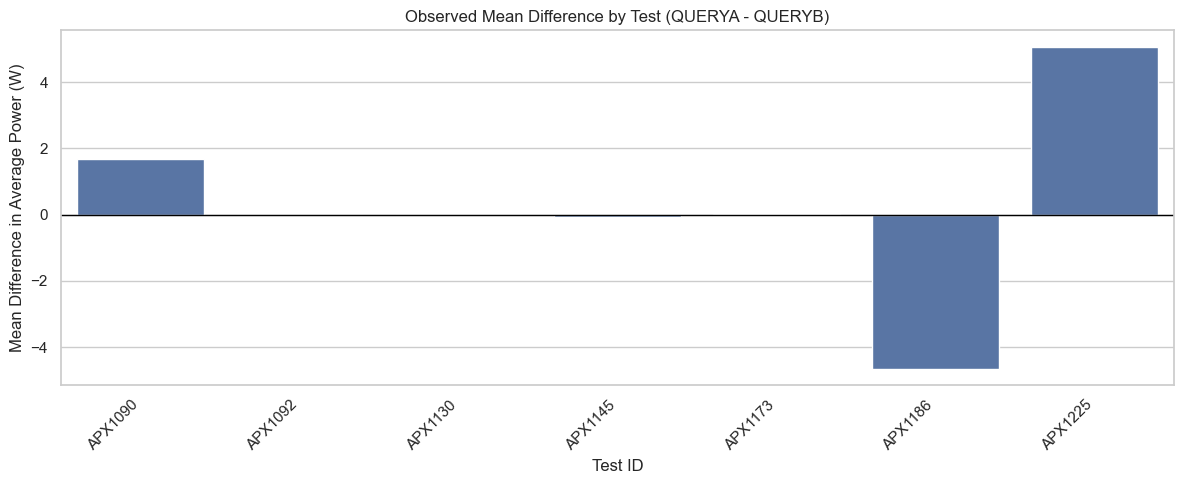

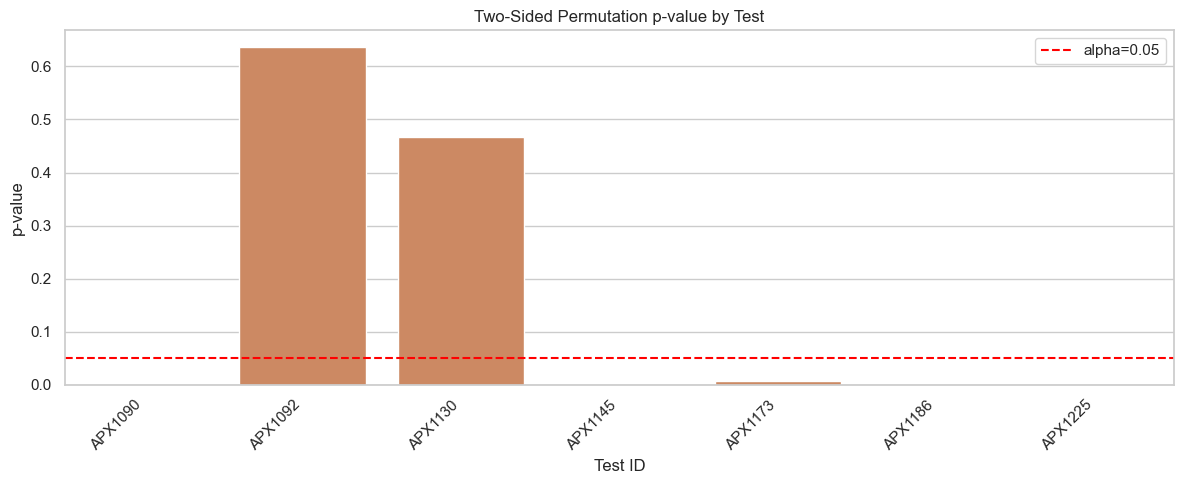

In [7]:
def permutation_test_mean_diff(df: pd.DataFrame, group_col: str, value_col: str, group_a: str, group_b: str, n_perm: int = 10000, seed: int = 42):
    a = df.loc[df[group_col] == group_a, value_col].dropna().to_numpy()
    b = df.loc[df[group_col] == group_b, value_col].dropna().to_numpy()

    if len(a) == 0 or len(b) == 0:
        raise ValueError(f"Missing data for one or both groups: {group_a}, {group_b}")

    observed = a.mean() - b.mean()
    pooled = np.concatenate([a, b])
    n_a = len(a)

    rng = np.random.default_rng(seed)
    diffs = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        perm = rng.permutation(pooled)
        diffs[i] = perm[:n_a].mean() - perm[n_a:].mean()

    p_left = (np.sum(diffs <= observed) + 1) / (n_perm + 1)
    p_right = (np.sum(diffs >= observed) + 1) / (n_perm + 1)
    p_two = (np.sum(np.abs(diffs) >= abs(observed)) + 1) / (n_perm + 1)

    return observed, p_left, p_right, p_two, diffs


ab_df = analysis_df[analysis_df["query_group"].isin(["QUERYA", "QUERYB"])].copy()
per_test_results = []
perm_diffs_by_test = {}

for test_id, test_group in ab_df.groupby("test_id"):
    groups_present = set(test_group["query_group"].dropna().unique())
    if not {"QUERYA", "QUERYB"}.issubset(groups_present):
        continue

    observed, p_left, p_right, p_two, perm_diffs = permutation_test_mean_diff(
        test_group,
        group_col="query_group",
        value_col="avg_power_w",
        group_a="QUERYA",
        group_b="QUERYB",
        n_perm=10000,
        seed=42,
    )

    perm_diffs_by_test[test_id] = perm_diffs
    per_test_results.append(
        {
            "test_id": test_id,
            "n_queryA": int((test_group["query_group"] == "QUERYA").sum()),
            "n_queryB": int((test_group["query_group"] == "QUERYB").sum()),
            "observed_mean_diff_A_minus_B_w": observed,
            "p_left_A_lt_B": p_left,
            "p_right_A_gt_B": p_right,
            "p_two_sided": p_two,
        }
    )

per_test_results_df = pd.DataFrame(per_test_results).sort_values("test_id")

if per_test_results_df.empty:
    print("No tests had both QUERYA and QUERYB for per-test A/B comparison.")
else:
    print("Permutation test results by test (A vs B within each test_id):")
    display(per_test_results_df)

    plt.figure(figsize=(12, 5))
    sns.barplot(data=per_test_results_df, x="test_id", y="observed_mean_diff_A_minus_B_w", color="#4C72B0")
    plt.axhline(0.0, color="black", linewidth=1)
    plt.title("Observed Mean Difference by Test (QUERYA - QUERYB)")
    plt.xlabel("Test ID")
    plt.ylabel("Mean Difference in Average Power (W)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    sns.barplot(data=per_test_results_df, x="test_id", y="p_two_sided", color="#DD8452")
    plt.axhline(0.05, color="red", linestyle="--", label="alpha=0.05")
    plt.title("Two-Sided Permutation p-value by Test")
    plt.xlabel("Test ID")
    plt.ylabel("p-value")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

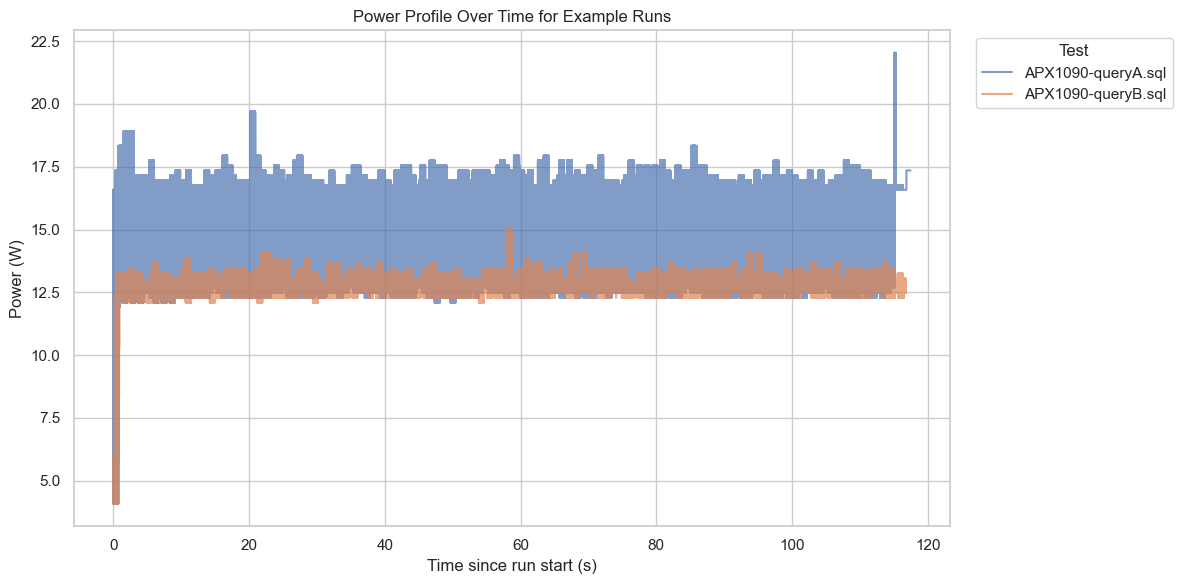

In [9]:
example_files = analysis_df["chunk_file"].dropna().head(70).tolist()

if example_files:
    profile_rows = []
    for file_name in example_files:
        chunk_df = pd.read_csv(file_name).sort_values("timestamp")
        chunk_df["time_s"] = (chunk_df["timestamp"] - chunk_df["timestamp"].min()) / 1000.0

        test_label = Path(file_name).name.split("__")[1] if "__" in Path(file_name).name else Path(file_name).stem
        chunk_df["test_label"] = test_label
        profile_rows.append(chunk_df)

    profile_df = pd.concat(profile_rows, ignore_index=True)

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=profile_df, x="time_s", y="power_w", hue="test_label", estimator=None, alpha=0.7)
    plt.title("Power Profile Over Time for Example Runs")
    plt.xlabel("Time since run start (s)")
    plt.ylabel("Power (W)")
    plt.legend(title="Test", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No chunk files available for profile plot.")

Combined sample counts by source/query group:


,source,query_group,samples
0,RAPL Package,QUERYA,220
1,RAPL Package,QUERYB,218
2,Sigless,QUERYA,262
3,Sigless,QUERYB,245


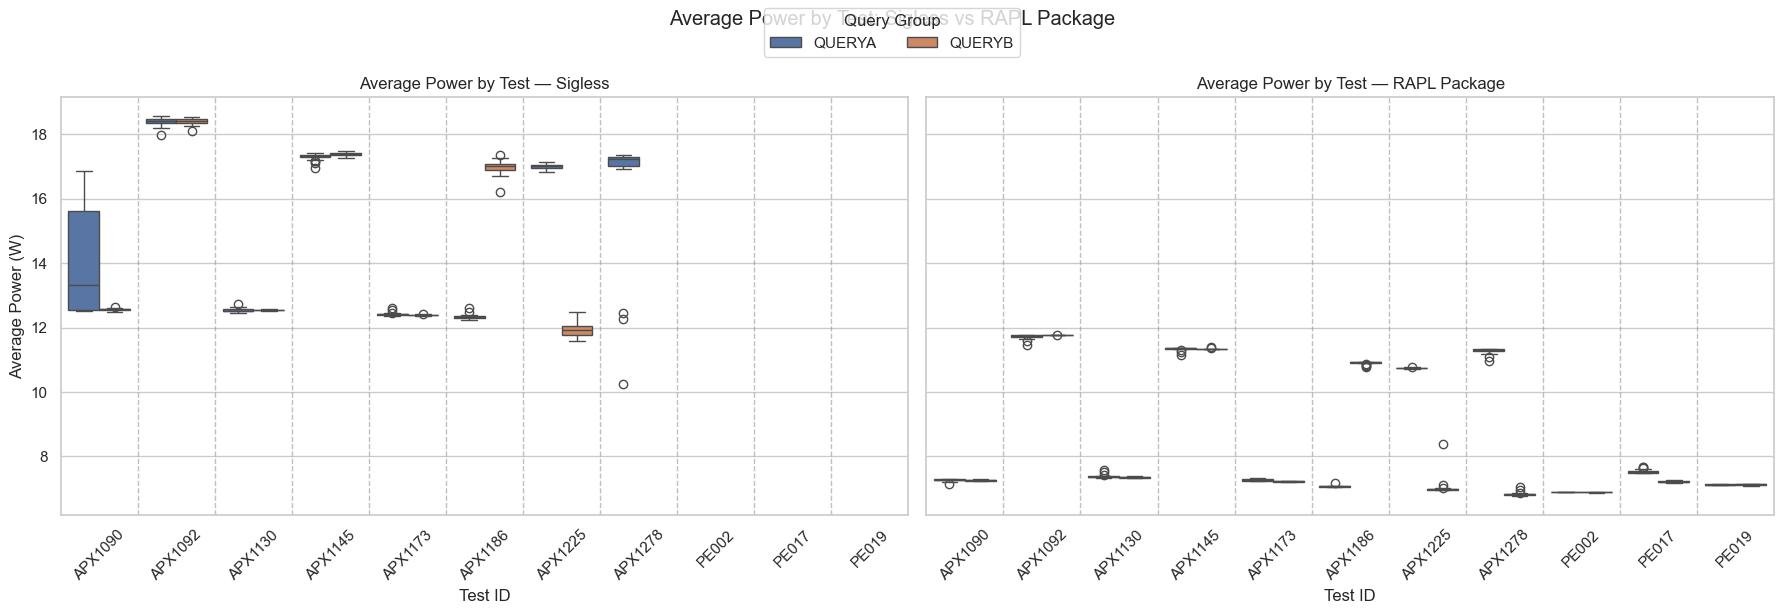

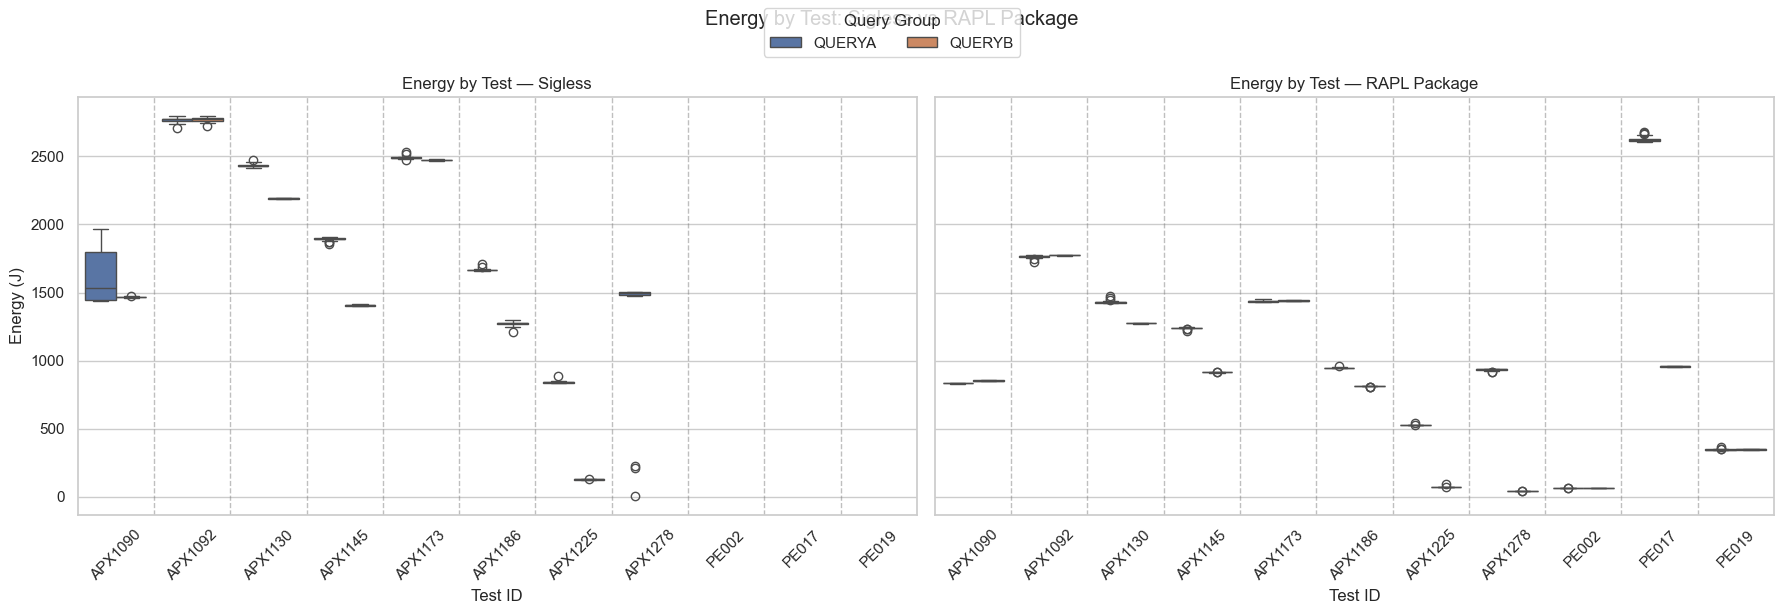

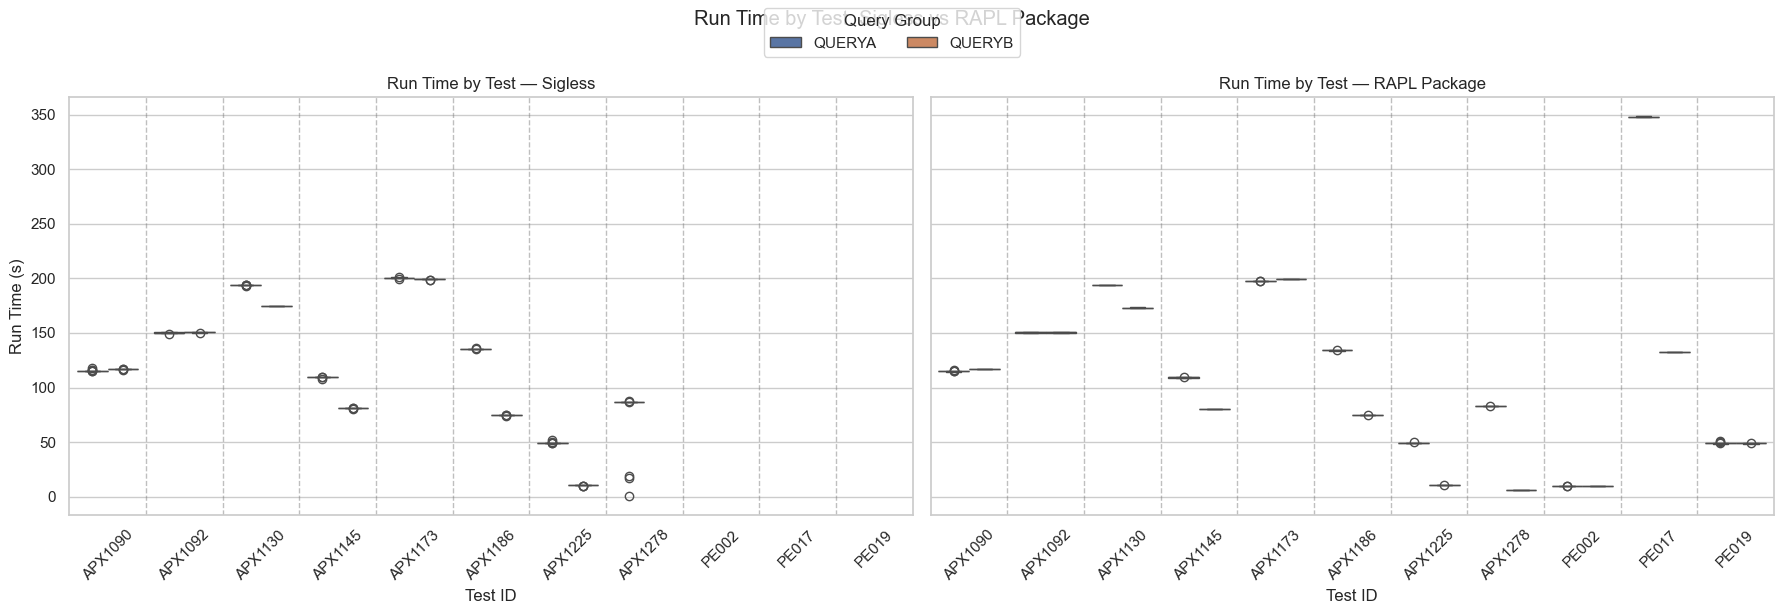

In [10]:
rapl_run_id = "296472940E2C0A29"
rapl_candidate_files = [
    Path("logs/query_timing1.csv"),
    Path("logs/query_timing2.csv"),
]

rapl_frames = []
for candidate_file in rapl_candidate_files:
    if not candidate_file.exists():
        continue

    candidate_df = pd.read_csv(candidate_file)
    candidate_df = candidate_df[candidate_df["run_id"] == rapl_run_id].copy()
    if candidate_df.empty:
        continue

    candidate_df["rapl_source_file"] = str(candidate_file)
    rapl_frames.append(candidate_df)

if not rapl_frames:
    raise ValueError(f"No RAPL timing rows found for run_id={rapl_run_id}")

rapl_df = pd.concat(rapl_frames, ignore_index=True)
rapl_df = rapl_df.drop_duplicates(
    subset=[
        "rapl_source_file",
        "run_id",
        "test_name",
        "loop_index",
        "total_elapsed_sec",
        "rapl_package_j",
    ]
).copy()

rapl_df["total_elapsed_sec"] = pd.to_numeric(rapl_df["total_elapsed_sec"], errors="coerce")
rapl_df["rapl_package_j"] = pd.to_numeric(rapl_df["rapl_package_j"], errors="coerce")
rapl_df = rapl_df.dropna(subset=["total_elapsed_sec", "rapl_package_j"]).copy()
rapl_df = rapl_df[(rapl_df["total_elapsed_sec"] > 0) & (rapl_df["rapl_package_j"] > 0)].copy()

rapl_df["test"] = rapl_df["test_name"]
rapl_df["query_group"] = rapl_df["test_name"].str.extract(r"(query[AB])", expand=False).str.upper()
rapl_df["test_id"] = rapl_df["test_name"].str.extract(r"^([^-]+)", expand=False)
rapl_df["avg_power_w"] = rapl_df["rapl_package_j"] / rapl_df["total_elapsed_sec"]
rapl_df["energy_j"] = rapl_df["rapl_package_j"]
rapl_df["measured_window_sec"] = rapl_df["total_elapsed_sec"]
rapl_df["source"] = "RAPL Package"

sigless_plot_df = analysis_df[[
    "test",
    "test_id",
    "query_group",
    "avg_power_w",
    "energy_j",
    "measured_window_sec",
]].copy()
sigless_plot_df["source"] = "Sigless"

rapl_plot_df = rapl_df[[
    "test",
    "test_id",
    "query_group",
    "avg_power_w",
    "energy_j",
    "measured_window_sec",
    "source",
]].copy()

combined_metric_df = pd.concat([sigless_plot_df, rapl_plot_df], ignore_index=True)
combined_metric_df = combined_metric_df[combined_metric_df["query_group"].isin(["QUERYA", "QUERYB"])].copy()

print("Combined sample counts by source/query group:")
display(
    combined_metric_df.groupby(["source", "query_group"])["test"]
    .count()
    .rename("samples")
    .reset_index()
    .sort_values(["source", "query_group"])
)

test_order = sorted(combined_metric_df["test_id"].dropna().unique())
source_order = ["Sigless", "RAPL Package"]
metric_plots = [
    ("avg_power_w", "Average Power by Test", "Average Power (W)"),
    ("energy_j", "Energy by Test", "Energy (J)"),
    ("measured_window_sec", "Run Time by Test", "Run Time (s)"),
]

for metric_col, metric_title, metric_ylabel in metric_plots:
    metric_df = combined_metric_df.dropna(subset=[metric_col]).copy()
    y_min = metric_df[metric_col].min()
    y_max = metric_df[metric_col].max()
    y_span = y_max - y_min
    y_pad = max(y_span * 0.05, 1e-9)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    legend_handles = None
    legend_labels = None

    for ax, source_name in zip(axes, source_order):
        source_df = metric_df[metric_df["source"] == source_name].copy()
        if source_df.empty:
            ax.set_visible(False)
            continue

        sns.boxplot(
            data=source_df,
            x="test_id",
            y=metric_col,
            hue="query_group",
            order=test_order,
            ax=ax,
        )

        for i in range(len(test_order) - 1):
            ax.axvline(i + 0.5, color="gray", linestyle="--", linewidth=1, alpha=0.5)

        ax.set_title(f"{metric_title} — {source_name}")
        ax.set_xlabel("Test ID")
        ax.set_ylabel(metric_ylabel)
        ax.tick_params(axis="x", rotation=45)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

        handles, labels = ax.get_legend_handles_labels()
        if handles and legend_handles is None:
            legend_handles, legend_labels = handles, labels
        if ax.legend_ is not None:
            ax.legend_.remove()

    if legend_handles:
        fig.legend(legend_handles, legend_labels, title="Query Group", loc="upper center", ncol=2)

    fig.suptitle(f"{metric_title}: Sigless vs RAPL Package", y=1.02)
    fig.tight_layout()
    plt.show()